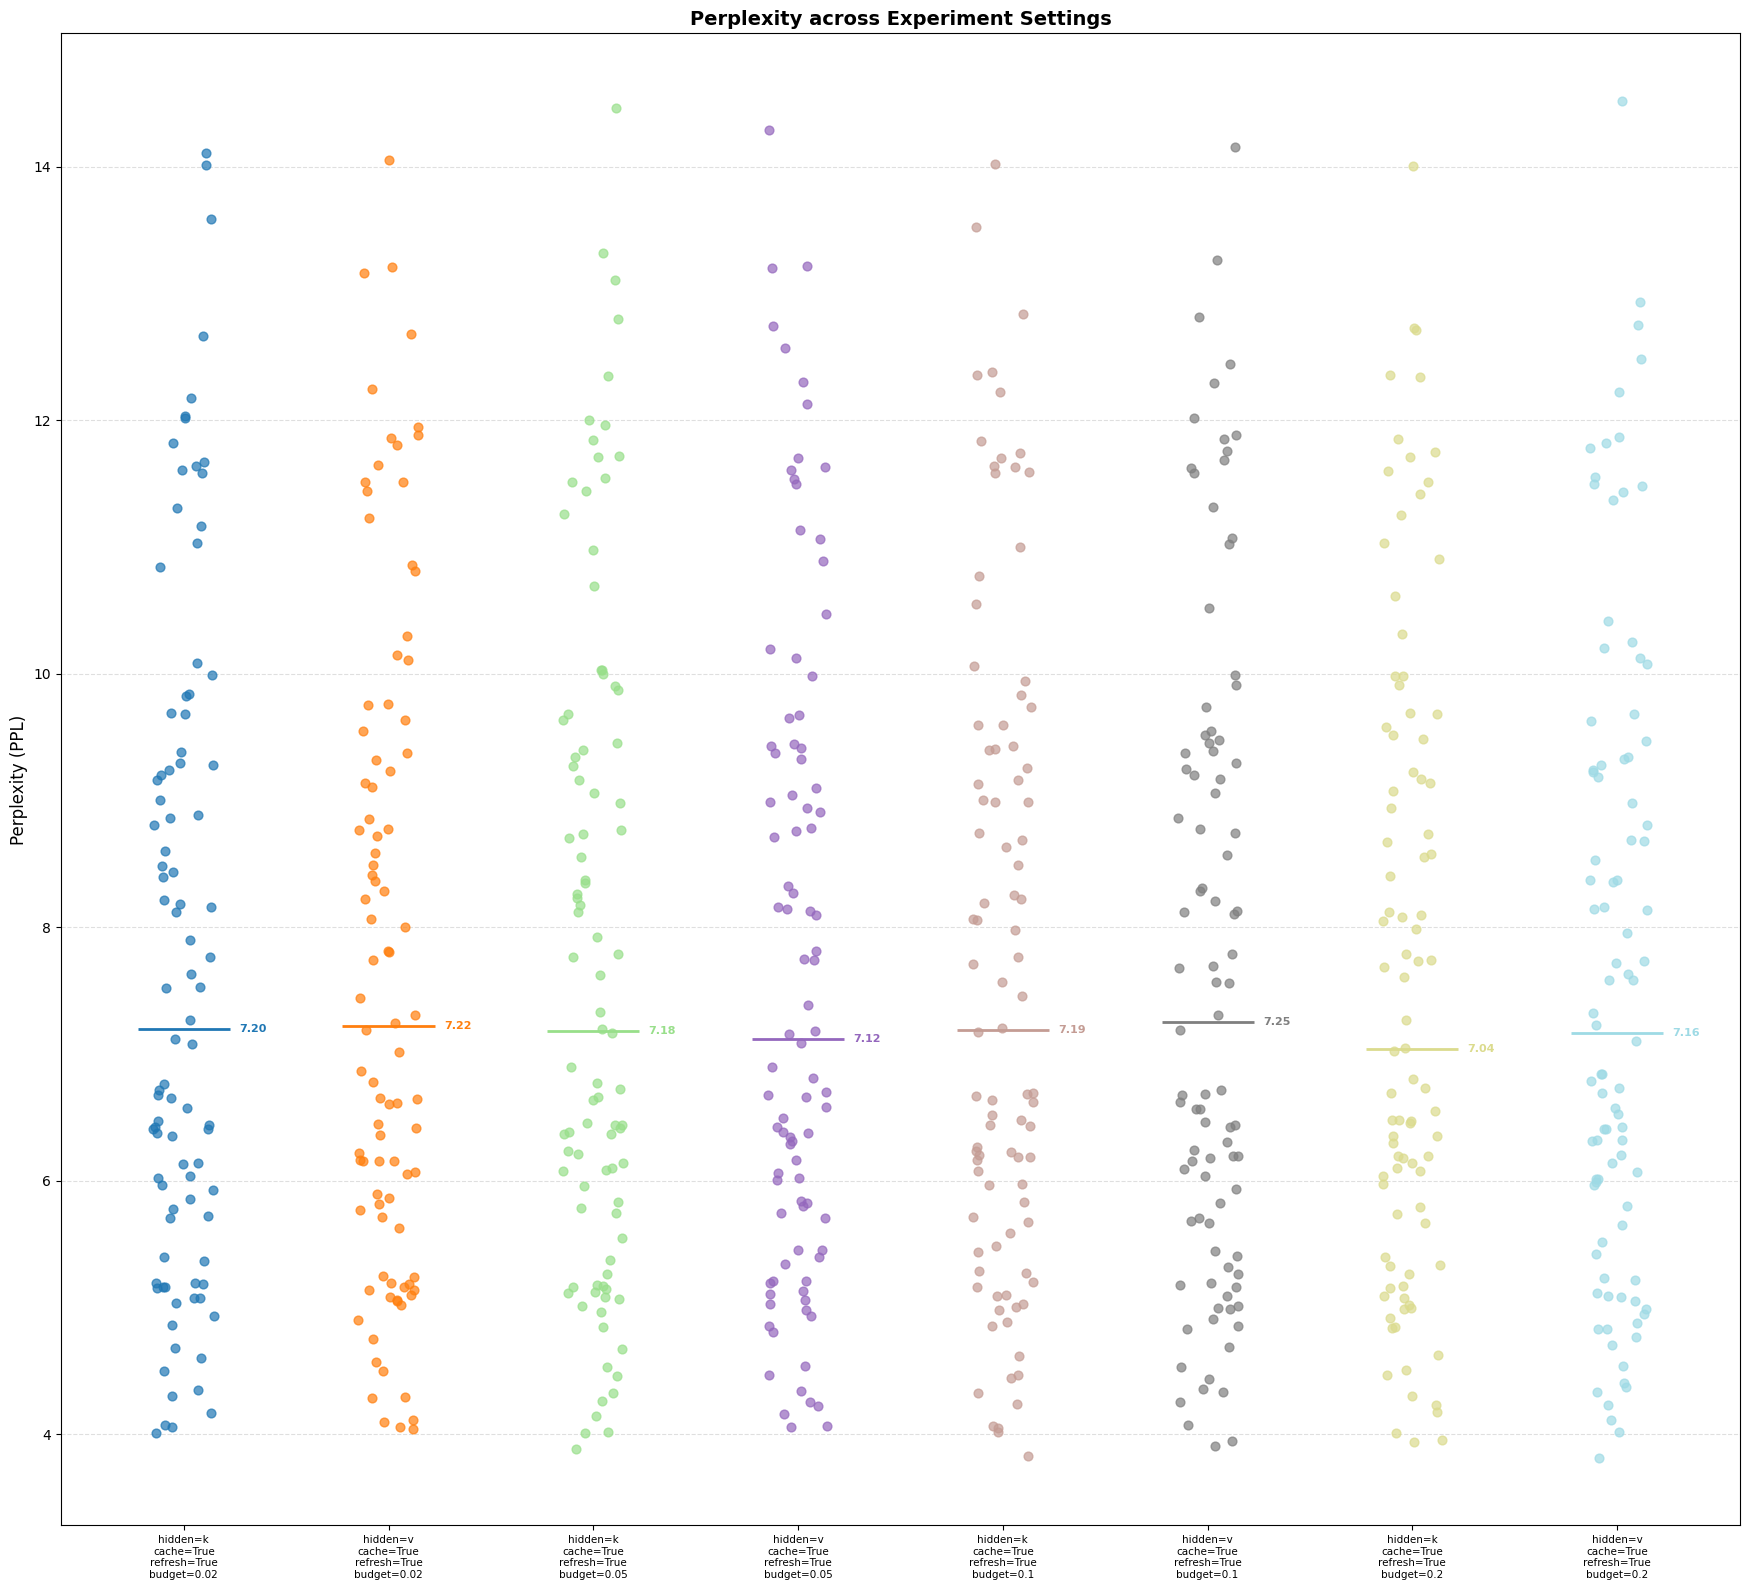

In [3]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict

# ── Config ──────────────────────────────────────────────────────────────────
DATA_DIR = "ppl_result"          # folder containing the data files
JITTER_AMOUNT = 0.15    # how much to scatter points horizontally
POINT_ALPHA   = 0.7
POINT_SIZE    = 40
# ────────────────────────────────────────────────────────────────────────────

FILE_PATTERN = re.compile(
    r"hidden_(?P<hidden_type>.+?)_cache_(?P<use_cache>.+?)_refresh_(?P<use_refresh>.+?)_budget_(?P<refresh_budget>.+?)$"
)
LINE_PATTERN = re.compile(
    r"\[(?P<timestamp>[^\]]+)\]\s+(?P<ppl>[\d.]+)\s*\|\s*(?P<conf>[\d.]+)"
)


def parse_filename(path):
    name = os.path.splitext(os.path.basename(path))[0]
    m = FILE_PATTERN.match(name)
    if not m:
        return None
    return m.groupdict()


def parse_file(path):
    ppls = []
    with open(path, "r") as f:
        for line in f:
            m = LINE_PATTERN.search(line.strip())
            if m:
                ppls.append(float(m.group("ppl")))
    return ppls


def build_label(params):
    return (
        f"hidden={params['hidden_type']}\n"
        f"cache={params['use_cache']}\n"
        f"refresh={params['use_refresh']}\n"
        f"budget={params['refresh_budget']}"
    )


def main():
    files = sorted(
        glob.glob(os.path.join(DATA_DIR, "hidden_*_cache_*_refresh_*_budget_*"))
    )
    if not files:
        print(f"No matching files found in '{DATA_DIR}'.")
        return

    # Collect data grouped by setting label
    groups = {}          # label -> list of ppl values
    param_map = {}       # label -> params dict (for sorting)

    for path in files:
        params = parse_filename(path)
        if params is None:
            print(f"  Skipping (unrecognised filename): {path}")
            continue
        ppls = parse_file(path)
        if not ppls:
            print(f"  Skipping (no data): {path}")
            continue
        label = build_label(params)
        groups.setdefault(label, []).extend(ppls)
        param_map[label] = params

    if not groups:
        print("No data parsed. Check file names and content format.")
        return

    def budget_sort_key(label):
        params = param_map[label]
        try:
            return float(params["refresh_budget"])
        except ValueError:
            return params["refresh_budget"]

    labels  = sorted(groups.keys(), key=budget_sort_key)
    x_pos   = np.arange(len(labels))          # integer tick positions

    # ── Colour map: one colour per setting ──────────────────────────────────
    colours = cm.tab20(np.linspace(0, 1, len(labels)))

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 2.2), 16))

    for i, label in enumerate(labels):
        ppls   = groups[label]
        n      = len(ppls)
        # Uniform random jitter in [-JITTER_AMOUNT, +JITTER_AMOUNT]
        jitter = np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=n)
        x_jit  = x_pos[i] + jitter

        ax.scatter(
            x_jit, ppls,
            color=colours[i],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
            label=f"n={n}",
        )

        # Median line for quick visual reference
        median_val = np.median(ppls)
        ax.hlines(
            median_val,
            x_pos[i] - JITTER_AMOUNT * 1.5,
            x_pos[i] + JITTER_AMOUNT * 1.5,
            colors=colours[i],
            linewidths=2,
            zorder=4,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=7.5, ha="center")
    ax.set_ylabel("Perplexity (PPL)", fontsize=12)
    ax.set_title("Perplexity across Experiment Settings", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_xlim(-0.6, len(labels) - 0.4)

    # Annotate each column with median value next to the median line
    for i, label in enumerate(labels):
        median_val = np.median(groups[label])
        ax.text(
            x_pos[i] + JITTER_AMOUNT * 1.8,
            median_val,
            f"{median_val:.2f}",
            ha="left", va="center", fontsize=8,
            color=colours[i], fontweight="bold"
        )

    plt.tight_layout()
    # out_path = os.path.join(DATA_DIR, "ppl_plot.png")
    # plt.savefig(out_path, dpi=150, bbox_inches="tight")
    # print(f"Plot saved to: {out_path}")
    plt.show()


if __name__ == "__main__":
    np.random.seed(42)   # reproducible jitter
    main()


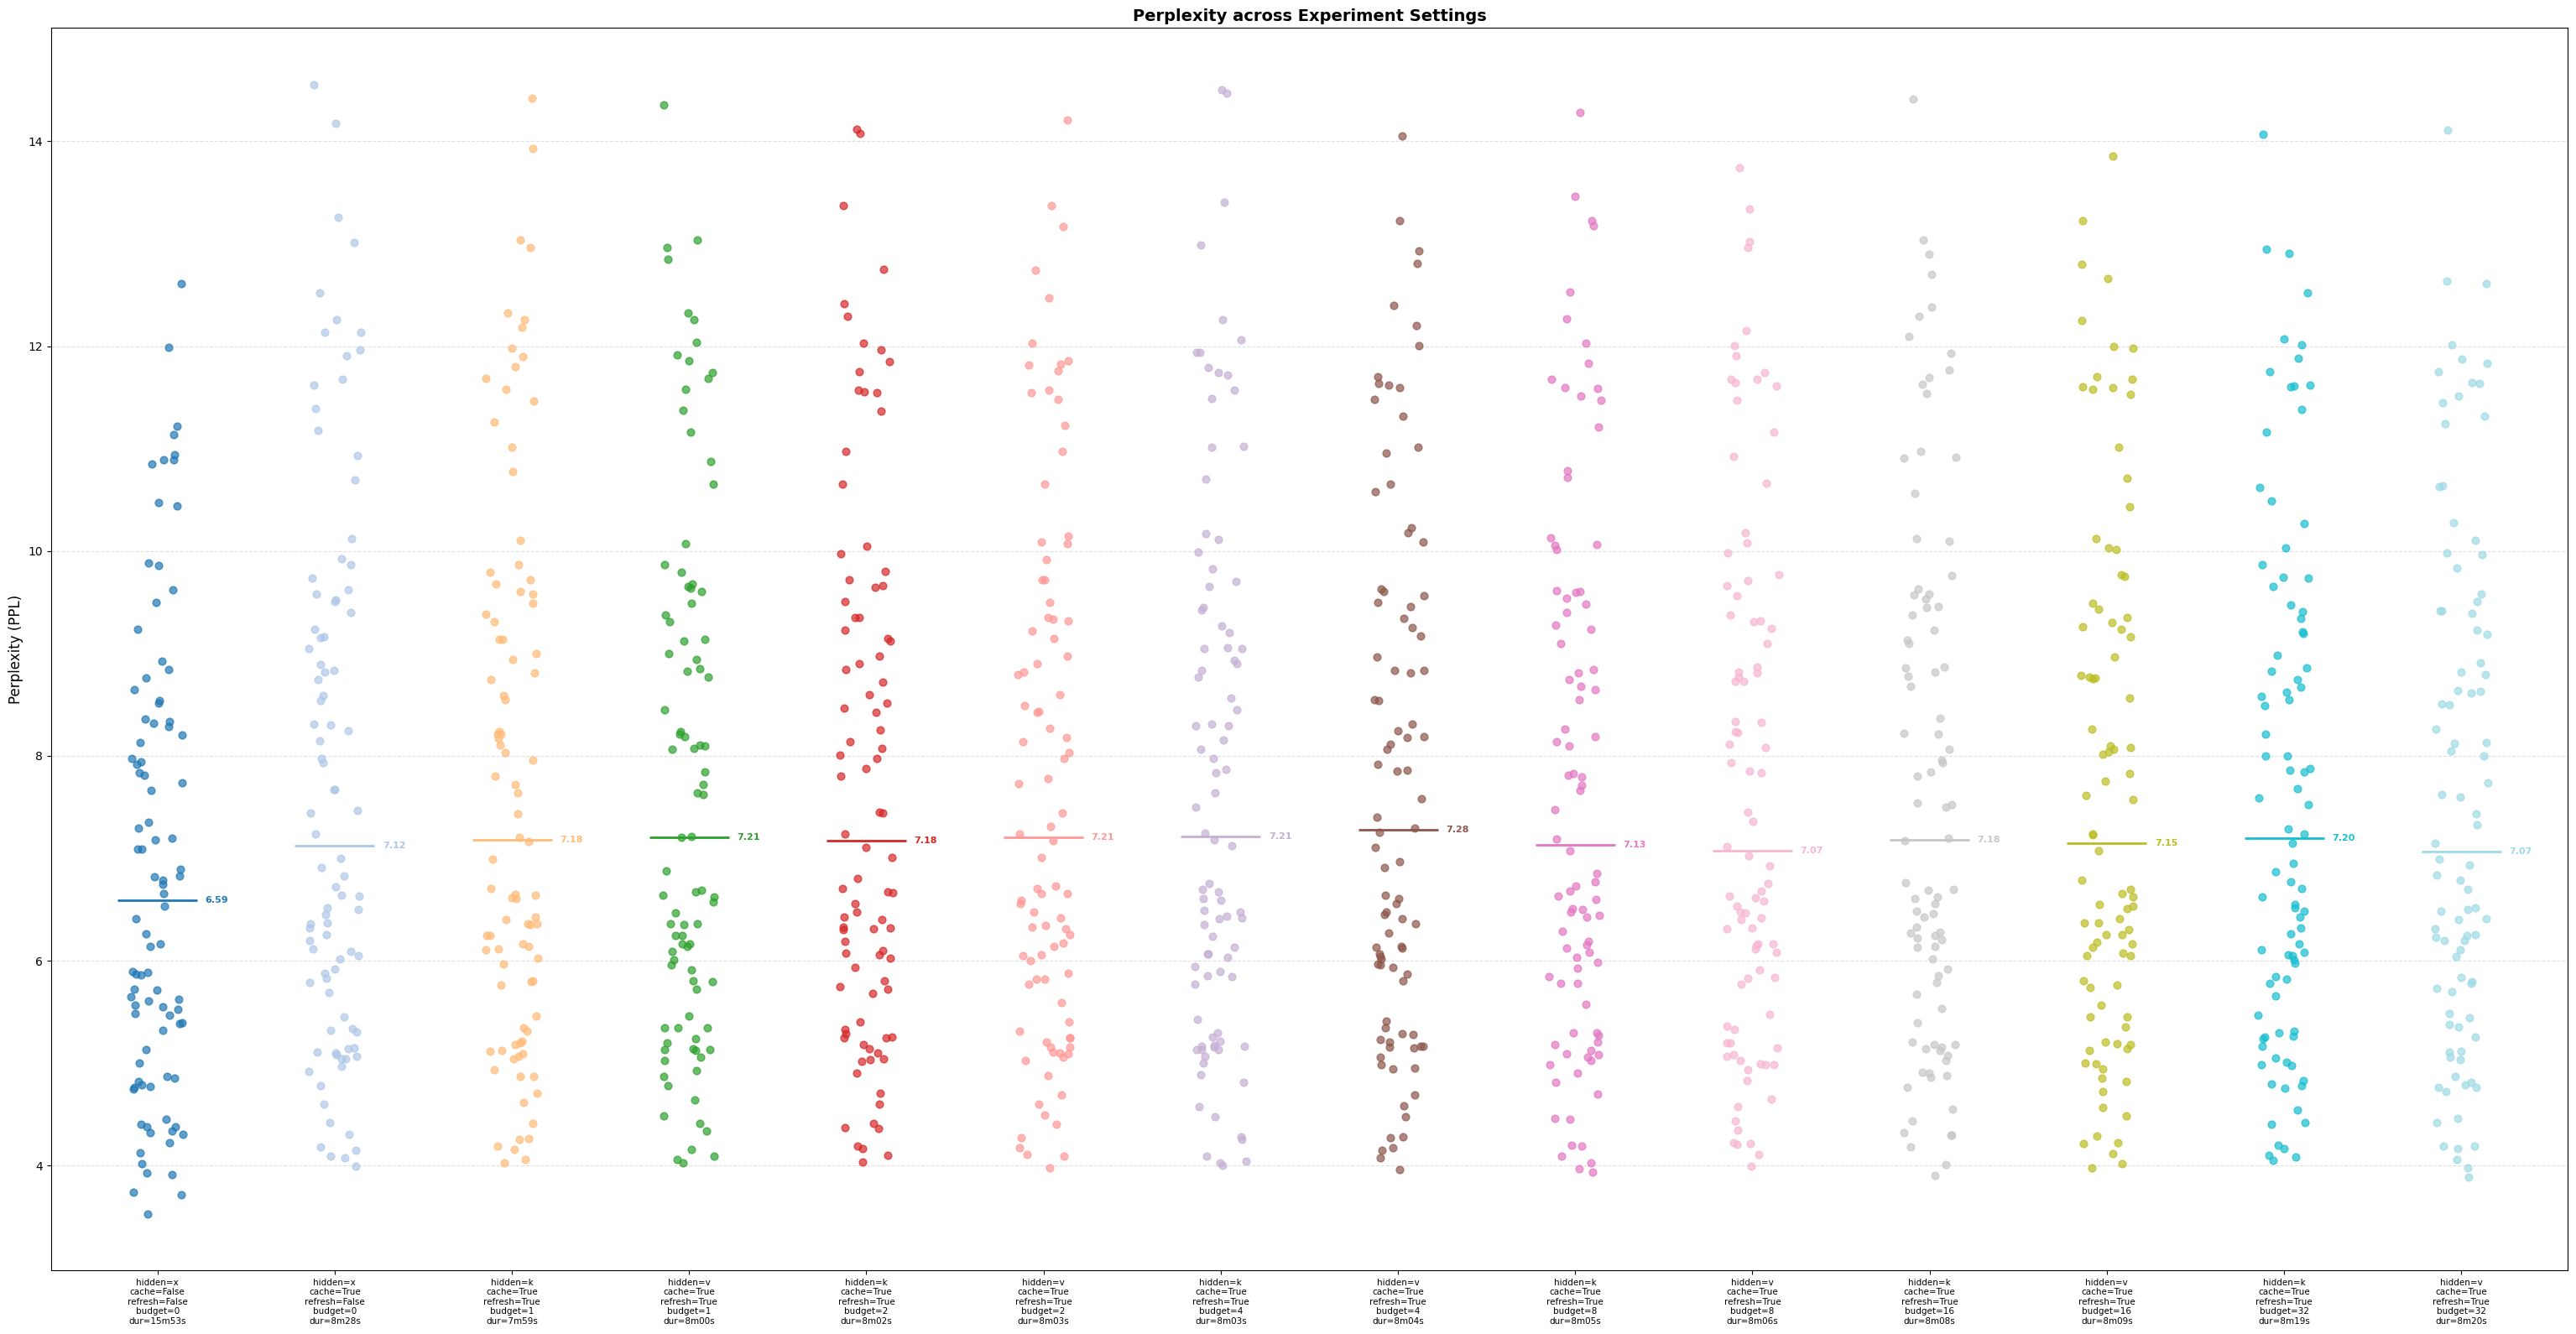

In [ ]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime

# ── Config ───────────────────────────────────────────────────────────────────
DATA_DIR      = "ppl_result"     # folder containing the data files
JITTER_AMOUNT = 0.15    # how much to scatter points horizontally
POINT_ALPHA   = 0.7
POINT_SIZE    = 40
# ─────────────────────────────────────────────────────────────────────────────

FILE_PATTERN = re.compile(
    r"hidden_(?P<hidden_type>.+?)_cache_(?P<use_cache>.+?)_refresh_(?P<use_refresh>.+?)_budget_(?P<refresh_budget>.+?)$"
)
LINE_PATTERN = re.compile(
    r"\[(?P<timestamp>[^\]]+)\]\s+(?P<ppl>[\d.]+)\s*\|\s*(?P<conf>[\d.]+)"
)
TS_FORMATS = [
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%dT%H:%M:%SZ",
    "%H:%M:%S",
    "%Y/%m/%d %H:%M:%S",
]


def parse_filename(path):
    name = os.path.splitext(os.path.basename(path))[0]
    m = FILE_PATTERN.match(name)
    return m.groupdict() if m else None


def parse_timestamp(ts_str):
    for fmt in TS_FORMATS:
        try:
            return datetime.strptime(ts_str.strip(), fmt)
        except ValueError:
            continue
    return None


def parse_file(path):
    """Returns (ppls, duration_seconds).
    duration = last_timestamp - first_timestamp in the file.
    """
    ppls, timestamps = [], []
    with open(path, "r") as f:
        for line in f:
            m = LINE_PATTERN.search(line.strip())
            if m:
                ppls.append(float(m.group("ppl")))
                ts = parse_timestamp(m.group("timestamp"))
                if ts:
                    timestamps.append(ts)

    duration = None
    if len(timestamps) >= 2:
        duration = (timestamps[-1] - timestamps[0]).total_seconds()
    return ppls, duration


def format_duration(seconds):
    if seconds is None:
        return "N/A"
    seconds = int(seconds)
    h, rem = divmod(seconds, 3600)
    m, s   = divmod(rem, 60)
    if h > 0:
        return f"{h}h{m:02d}m{s:02d}s"
    elif m > 0:
        return f"{m}m{s:02d}s"
    else:
        return f"{s}s"


def build_label(params, avg_duration=None):
    dur_str = format_duration(avg_duration)
    return (
        f"hidden={params['hidden_type']}\n"
        f"cache={params['use_cache']}\n"
        f"refresh={params['use_refresh']}\n"
        f"budget={params['refresh_budget']}\n"
        f"dur={dur_str}"
    )


def main():
    files = sorted(
        glob.glob(os.path.join(DATA_DIR, "hidden_*_cache_*_refresh_*_budget_*"))
    )
    if not files:
        print(f"No matching files found in '{DATA_DIR}'.")
        return

    # settings_key -> list of ppls / durations
    groups    = {}
    param_map = {}
    durations = {}

    for path in files:
        params = parse_filename(path)
        if params is None:
            print(f"  Skipping (unrecognised filename): {path}")
            continue
        ppls, duration = parse_file(path)
        if not ppls:
            print(f"  Skipping (no data): {path}")
            continue

        key = (
            params["hidden_type"], params["use_cache"],
            params["use_refresh"], params["refresh_budget"],
        )
        groups.setdefault(key, []).extend(ppls)
        param_map[key] = params
        durations.setdefault(key, [])
        if duration is not None:
            durations[key].append(duration)

    if not groups:
        print("No data parsed. Check file names and content format.")
        return

    # Sort by budget
    def budget_sort_key(key):
        try:
            return float(param_map[key]["refresh_budget"])
        except ValueError:
            return param_map[key]["refresh_budget"]

    sorted_keys = sorted(groups.keys(), key=budget_sort_key)

    # Build display labels (average duration across files with same setting)
    labels = []
    for key in sorted_keys:
        dur_list = durations.get(key, [])
        avg_dur  = sum(dur_list) / len(dur_list) if dur_list else None
        labels.append(build_label(param_map[key], avg_dur))

    x_pos   = np.arange(len(sorted_keys))

    # Colour map: one colour per setting
    colours = cm.tab20(np.linspace(0, 1, len(sorted_keys)))

    fig, ax = plt.subplots(figsize=(max(10, len(sorted_keys) * 2.2), 16))

    for i, key in enumerate(sorted_keys):
        ppls   = groups[key]
        n      = len(ppls)
        jitter = np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=n)
        x_jit  = x_pos[i] + jitter

        ax.scatter(
            x_jit, ppls,
            color=colours[i],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
        )

        # Median line
        median_val = np.median(ppls)
        ax.hlines(
            median_val,
            x_pos[i] - JITTER_AMOUNT * 1.5,
            x_pos[i] + JITTER_AMOUNT * 1.5,
            colors=colours[i],
            linewidths=2,
            zorder=4,
        )

        # Median value label next to the line
        ax.text(
            x_pos[i] + JITTER_AMOUNT * 1.8,
            median_val,
            f"{median_val:.2f}",
            ha="left", va="center", fontsize=8,
            color=colours[i], fontweight="bold",
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=7.5, ha="center")
    ax.set_ylabel("Perplexity (PPL)", fontsize=12)
    ax.set_title("Perplexity across Experiment Settings", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_xlim(-0.6, len(sorted_keys) - 0.4)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    np.random.seed(42)
    main()